<a href="https://colab.research.google.com/github/jermeyjohnson31-lab/Data_analytics/blob/main/Class_Assisgment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Load the DataFrame

In [2]:
import pandas as pd

url = "https://noaaocm.blob.core.windows.net/ais/csv2/csv2025/ais-2025-01-08.csv.zst"

df = pd.read_csv(url)
df.head()

,mmsi,base_date_time,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
0,367793030,2025-01-08 00:00:00,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
1,338160209,2025-01-08 00:00:00,-119.69199,34.40719,0.0,106.3,NaN,WESTERLY,NaN,NaN,36.0,NaN,11.0,4.0,NaN,NaN,B
2,266283000,2025-01-08 00:00:01,-74.24126,38.41834,15.5,187.9,190.0,OBERON,IMO9377509,SKJF,70.0,0.0,237.0,32.0,9.1,70.0,A
3,368013620,2025-01-08 00:00:10,-74.04712,40.10181,0.0,252.3,NaN,MARKET PRICE,NaN,WDJ8153,30.0,NaN,17.0,6.0,NaN,NaN,B
4,368144150,2025-01-08 00:00:09,-119.22453,34.16235,0.0,169.6,NaN,SILENT LADY,NaN,WDL5759,37.0,NaN,12.0,5.0,NaN,NaN,B


Convert & Set DateTime Index


In [4]:
df["base_date_time"] = pd.to_datetime(df["base_date_time"])

df = df.set_index("base_date_time")
df = df.sort_index()

df.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5929631 entries, 2025-01-08 00:00:00 to 2025-01-08 23:59:59
Data columns (total 16 columns):
 #   Column       Dtype  
---  ------       -----  
 0   mmsi         int64  
 1   longitude    float64
 2   latitude     float64
 3   sog          float64
 4   cog          float64
 5   heading      float64
 6   vessel_name  object 
 7   imo          object 
 8   call_sign    object 
 9   vessel_type  float64
 10  status       float64
 11  length       float64
 12  width        float64
 13  draft        float64
 14  cargo        float64
 15  transceiver  object 
dtypes: float64(11), int64(1), object(4)
memory usage: 769.1+ MB


Clean the Data "remove null SOG"

In [6]:
df = df.dropna(subset=["sog"])
df.head()

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver
base_date_time,,,,,,,,,,,,,,,,
2025-01-08,367793030,-122.40506,47.68588,4.6,155.5,NaN,WN1622SL,NaN,WDJ5962,37.0,NaN,10.0,3.0,NaN,NaN,B
2025-01-08,368120080,-89.86124,29.60222,0.0,303.0,NaN,JET 1,NaN,WDL3278,50.0,NaN,10.0,8.0,NaN,50.0,A
2025-01-08,367003780,-93.97799,29.81822,0.1,263.8,72.0,PHILIP,NaN,WDF2430,52.0,12.0,22.0,10.0,3.0,57.0,A
2025-01-08,368242090,-76.40403,39.00670,0.0,270.1,NaN,GALE,NaN,WDM8302,52.0,0.0,20.0,8.0,NaN,52.0,A
2025-01-08,367606370,-95.10048,29.77049,1.1,357.3,5.0,PAT BOONE,NaN,WDH3305,52.0,0.0,16.0,8.0,2.6,52.0,A


First Analysis: When Are Boats Out?

In [18]:
df["hour"] = df.index.hour

In [17]:
boats_per_hour = df.groupby("hour")["mmsi"].nunique()

Plot


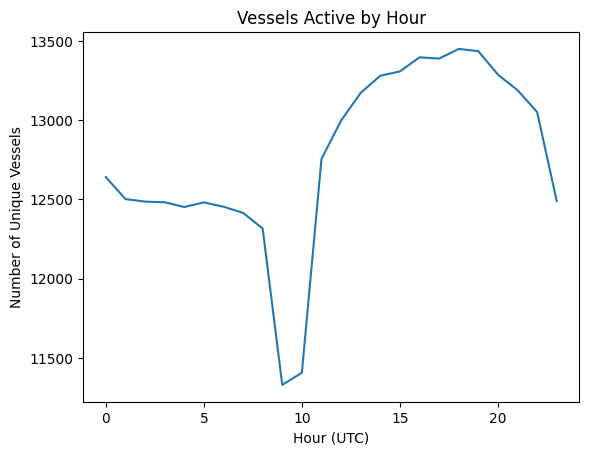

In [16]:
import matplotlib.pyplot as plt

boats_per_hour.plot()
plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Unique Vessels")
plt.title("Vessels Active by Hour")
plt.show()

Find busiest and quietest times


In [19]:
max_hour = boats_per_hour.idxmax()
min_hour = boats_per_hour.idxmin()

print("Most boats at hour:", max_hour)
print("Least boats at hour:", min_hour)

Most boats at hour: 18
Least boats at hour: 9


EX: More boats during daylight/business hours
Fewer boats late at night
This matches expected maritime activity patterns

###Second Analysis: Henry Hudson (MMSI: 366651000)

Filter that vessel

In [26]:
henry = df[df["mmsi"] == 366651000].copy()
henry = henry.sort_index()
henry.head()

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour
base_date_time,,,,,,,,,,,,,,,,,
2025-01-08 00:00:04,366651000,-74.02250,40.75867,0.0,283.6,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0
2025-01-08 00:01:14,366651000,-74.02209,40.75843,5.5,129.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0
2025-01-08 00:02:45,366651000,-74.01930,40.75736,11.2,114.7,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0
2025-01-08 00:03:55,366651000,-74.01468,40.75834,11.6,61.5,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0
2025-01-08 00:05:06,366651000,-74.01090,40.76075,11.8,61.2,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0


Acceleration column (change in speed)

In [34]:
henry["acceleration"] = henry["sog"].diff()
henry.head()

,mmsi,longitude,latitude,sog,cog,heading,vessel_name,imo,call_sign,vessel_type,status,length,width,draft,cargo,transceiver,hour,acceleration,duration
base_date_time,,,,,,,,,,,,,,,,,,,
2025-01-08 00:00:04,366651000,-74.02250,40.75867,0.0,283.6,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,NaN,NaT
2025-01-08 00:01:14,366651000,-74.02209,40.75843,5.5,129.9,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.5,0 days 00:01:10
2025-01-08 00:02:45,366651000,-74.01930,40.75736,11.2,114.7,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,5.7,0 days 00:01:31
2025-01-08 00:03:55,366651000,-74.01468,40.75834,11.6,61.5,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.4,0 days 00:01:10
2025-01-08 00:05:06,366651000,-74.01090,40.76075,11.8,61.2,NaN,HENRY HUDSON,NaN,WBP8761,60.0,0.0,30.0,8.0,3.1,60.0,A,0,0.2,0 days 00:01:11


Duration column (time difference)

In [36]:
henry["duration"] = henry.index.to_series().diff()
henry[["sog", "acceleration", "duration"]].head()

,sog,acceleration,duration
base_date_time,,,
2025-01-08 00:00:04,0.0,NaN,NaT
2025-01-08 00:01:14,5.5,5.5,0 days 00:01:10
2025-01-08 00:02:45,11.2,5.7,0 days 00:01:31
2025-01-08 00:03:55,11.6,0.4,0 days 00:01:10
2025-01-08 00:05:06,11.8,0.2,0 days 00:01:11


In [39]:
active = henry[henry["acceleration"] > 0]
total_active_time = active["duration"].sum()
henry["duration"].describe()

,duration
count,685
mean,0 days 00:02:06.049635036
std,0 days 00:17:43.838773559
min,0 days 00:00:10
25%,0 days 00:01:09
50%,0 days 00:01:12
75%,0 days 00:01:31
max,0 days 07:44:21


In [40]:
total_active_time = active["duration"].sum()

print("Total engine active time:", total_active_time)

Total engine active time: 0 days 08:03:24


In [41]:
print(active[["sog", "acceleration", "duration"]].head())

                      sog  acceleration        duration
base_date_time                                         
2025-01-08 00:01:14   5.5           5.5 0 days 00:01:10
2025-01-08 00:02:45  11.2           5.7 0 days 00:01:31
2025-01-08 00:03:55  11.6           0.4 0 days 00:01:10
2025-01-08 00:05:06  11.8           0.2 0 days 00:01:11
2025-01-08 00:09:06   0.1           0.1 0 days 00:01:11
